In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step-1: Data Understanding

In [43]:
df = pd.read_csv("C:\\Users\\Abhishek Upadhye\\Desktop\\Carrer247\\Project\\Stastics\\US_Customer_Insights_Dataset.csv")
df.head()

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103


In [6]:
df.shape

(10675, 12)

In [12]:
df.columns

Index(['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Age', 'Married',
       'NumPets', 'JoinDate', 'TransactionDate', 'MonthlySpend',
       'DaysSinceLastInteraction'],
      dtype='object')

In [13]:
df.info

<bound method DataFrame.info of       CustomerID                Name       State    Education      Gender  \
0      CUST10319         Scott Perez     Florida  High School  Non-Binary   
1      CUST10695     Jennifer Burton  Washington       Master        Male   
2      CUST10297     Michelle Rogers     Arizona       Master      Female   
3      CUST10103    Brooke Hendricks       Texas       Master        Male   
4      CUST10219         Karen Johns       Texas  High School      Female   
...          ...                 ...         ...          ...         ...   
10670  CUST10833        Steven Burns     Georgia          PhD      Female   
10671  CUST10620         Jesse Pratt       Texas       Master        Male   
10672  CUST10449          John Lloyd     Arizona       Master  Non-Binary   
10673  CUST10020  Christopher Sparks     Florida     Bachelor      Female   
10674  CUST10267    Melissa Marshall     Arizona    Associate  Non-Binary   

       Age Married  NumPets JoinDate Transa

In [14]:
df.isnull().sum()

CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

In [15]:
num_col = df.select_dtypes(include=['int64', 'float64']).columns
cat_col = df.select_dtypes(include=['object']).columns

num_col, cat_col

(Index(['Age', 'NumPets', 'MonthlySpend', 'DaysSinceLastInteraction'], dtype='object'),
 Index(['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Married',
        'JoinDate', 'TransactionDate'],
       dtype='object'))

In [12]:
df['Gender'].value_counts()

Gender
Male          3791
Non-Binary    3471
Female        3413
Name: count, dtype: int64

In [13]:
df['Education'].value_counts()

Education
Master         2269
Associate      2153
Bachelor       2127
High School    2120
PhD            2006
Name: count, dtype: int64

In [14]:
df['Married'].value_counts() 

Married
No     5583
Yes    5092
Name: count, dtype: int64

### Step-2

In [16]:
df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction']].describe()

,Age,MonthlySpend,DaysSinceLastInteraction
count,10675.000000,10675.000000,10675.000000
mean,49.474567,331.610315,538.469883
std,18.221365,225.799253,398.766747
min,18.000000,3.890000,1.000000
25%,35.000000,165.495000,218.000000
50%,49.000000,282.110000,445.000000
75%,66.000000,443.255000,788.500000
max,80.000000,1740.420000,1791.000000


In [17]:
df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction']].agg(['mean', 'median', 'std'])

,Age,MonthlySpend,DaysSinceLastInteraction
mean,49.474567,331.610315,538.469883
median,49.000000,282.110000,445.000000
std,18.221365,225.799253,398.766747


In [18]:
df[['Gender', 'Education', 'Married']].mode()

,Gender,Education,Married
0,Male,Master,No


### Step-3 Data Visualization

#### Plot histograms and boxplots for Age, MonthlySpend

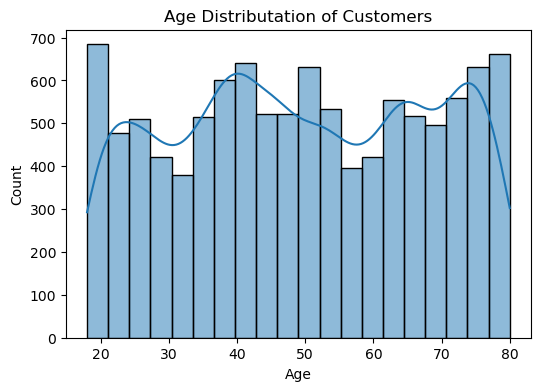

In [19]:
# Hist plot - Age Distributation

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distributation of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

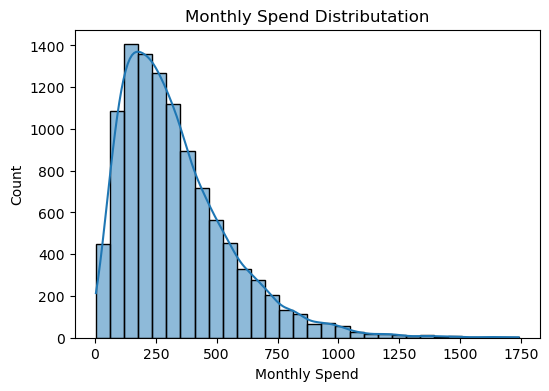

In [21]:
# Hist plot - Monthly spend Distributation

plt.figure(figsize=(6,4))
sns.histplot(df['MonthlySpend'], bins=30, kde=True)
plt.title('Monthly Spend Distributation')
plt.xlabel('Monthly Spend')
plt.ylabel('Count')
plt.show()

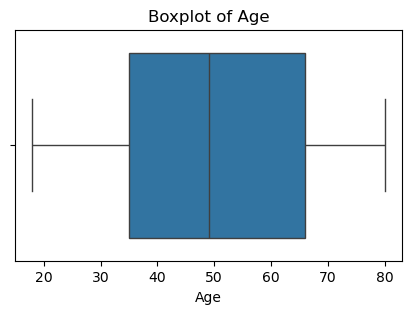

In [22]:
# Box Plot - Age

plt.figure(figsize=(5,3))
sns.boxplot(x=df['Age'])
plt.title('Boxplot of Age')
plt.show()

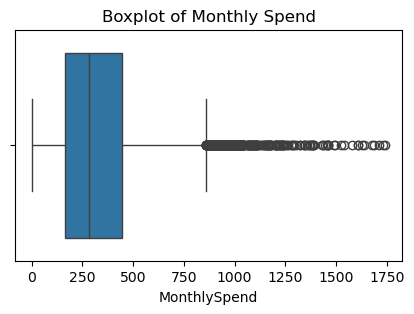

In [23]:
# Boxplot - Monthly Spend

plt.figure(figsize=(5,3))
sns.boxplot(x=df['MonthlySpend'])
plt.title('Boxplot of Monthly Spend')
plt.show() 

#### bar chart for Gender, Education, State

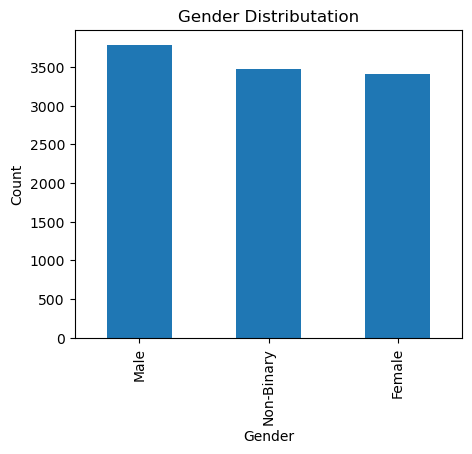

In [24]:
# Bar Chart - Gender Distributation

plt.figure(figsize=(5,4))
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distributation')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

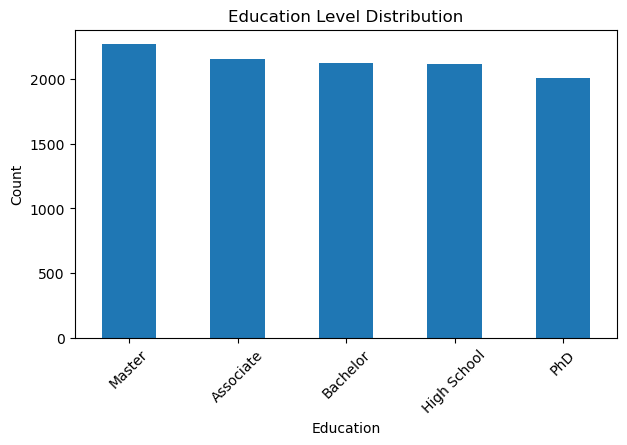

In [25]:
# Bar Chart - Education Levels

plt.figure(figsize=(7,4))
df['Education'].value_counts().plot(kind='bar')
plt.title('Education Level Distribution')
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### Scatterplot: Age vs MonthlySpend

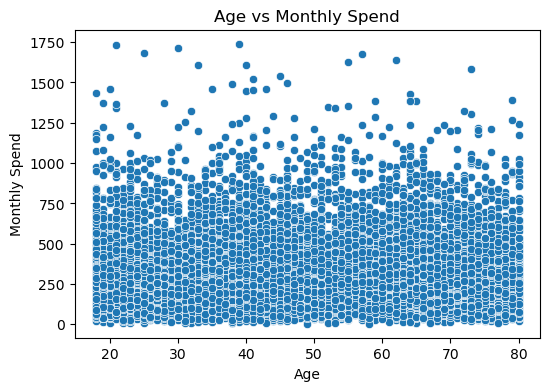

In [31]:
# Scatter Plot - Age vs MonthlySpend

plt.figure(figsize=(6,4))
sns.scatterplot(x='Age', y='MonthlySpend', data=df)
plt.title('Age vs Monthly Spend')
plt.xlabel('Age')
plt.ylabel('Monthly Spend')
plt.show()

#### KDE: Spending behavior by education level or marital status

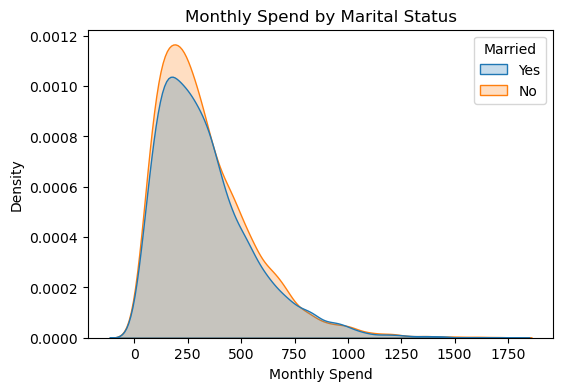

In [32]:
# KDE Plot - Spending behavior by education level or marital status

plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x='MonthlySpend', hue='Married', fill=True)
plt.title('Monthly Spend by Marital Status')
plt.xlabel('Monthly Spend')
plt.show()

### Step-4

In [33]:
cm = df[['Age','NumPets','MonthlySpend','DaysSinceLastInteraction']].corr()
cm

,Age,NumPets,MonthlySpend,DaysSinceLastInteraction
Age,1.000000,-0.023035,-0.012323,-0.003970
NumPets,-0.023035,1.000000,0.020647,-0.055227
MonthlySpend,-0.012323,0.020647,1.000000,0.006081
DaysSinceLastInteraction,-0.003970,-0.055227,0.006081,1.000000


In [34]:
df.groupby('Gender')['MonthlySpend'].mean()

Gender
Female        331.361310
Male          333.174068
Non-Binary    330.147240
Name: MonthlySpend, dtype: float64

In [35]:
df.groupby('Education')['MonthlySpend'].mean().sort_values(ascending=False)

Education
Master         334.252305
High School    332.215712
Bachelor       331.884753
PhD            331.690090
Associate      327.884408
Name: MonthlySpend, dtype: float64

In [36]:
df.groupby('State')['MonthlySpend'].mean().sort_values(ascending=False)

State
Arizona       341.489135
Ohio          340.187860
California    339.183492
Illinois      332.589591
New York      332.151244
Washington    329.444078
Georgia       328.354648
Florida       327.696892
Colorado      323.083462
Texas         319.506770
Name: MonthlySpend, dtype: float64

### Step-5

Business Question: 1
  Do male and female customers differ in their average monthly spending?

Statistical Test: 
  Independent Two-Sample t-test

Null Hypothesis (H₀):  
  male and female customers spend about the same on average each month.

Alternative Hypothesis (H₁):
  there is a clear difference in average monthly spending between male and female customers.
  
------------------------------------------------------------------------------------------

Business Question: 2
Does education level have an impact on average monthly spending?

Statistical Test: 
One-Way ANOVA

Null Hypothesis (H₀):  
- There is no difference in mean monthly spending across education levels.

Alternative Hypothesis (H₁): 
- average monthly spending is not the same across all education levels.

------------------------------------------------------------------------------------------

Business Question: 3
Is marital status related to the number of pets owned? 

Statistical Test: Chi-square test

Null Hypothesis (H₀):  
 - Marriage has nothing to do with pet ownership

Alternative Hypothesis (H₁):  
 - Marriage affect pet ownership.

------------------------------------------------------------------------------------------

Business Question: 4
Are older customers less active compared to younger customers?

Statistical Test: Pearson Correlation

Null Hypothesis (H₀):  
 - age is not related to the number of days since the last interaction.

Alternative Hypothesis (H₁):  
 - It looks like age is related to the time since the last interaction.

------------------------------------------------------------------------------------------

Business Question: 5 
Does average monthly spending differ across states?

Statistical Test: One-Way ANOVA

Null Hypothesis (H₀):  
- people spend about the same amount per month on average in all states.

Alternative Hypothesis (H₁):  
- at least one state has a different average monthly spending.

------------------------------------------------------------------------------------------

### Step-6

In [6]:
# 1 Gender vs Monthly Spending
from scipy.stats import ttest_ind

m_spend = df[df['Gender'] == 'Male']['MonthlySpend']
f_spend = df[df['Gender'] == 'Female']['MonthlySpend']

ts, pval = ttest_ind(m_spend, f_spend, equal_var=False)
ts, pval

(0.3391303706925083, 0.7345215220030699)

In [ ]:
p = 0.7345
- Decision: Fail to reject H₀
- Interpretation: Male and female customers spend about the same on average each month.

In [37]:
# 2 Education Level vs Monthly Spending
from scipy.stats import f_oneway

groups = [df[df['Education'] == edu]['MonthlySpend'] 
          for edu in df['Education'].unique()]
f_stat, p_val = f_oneway(*groups) 
f_stat, p_val

(0.22880668673709165, 0.922359467759936)

In [ ]:
p = 0.9224

- Decision: Fail to reject H₀
- Interpretation: Monthly spending looks similar regardless of education level.

In [8]:
# 3 Age vs Days Since Last Interaction
from scipy.stats import pearsonr

corr, p_val = pearsonr(df['Age'], df['DaysSinceLastInteraction'])
corr, p_val

(-0.003970230104955046, 0.6816905437300954)

In [ ]:
p = 0.6817, correlation ≈ 0
- Decision: Fail to reject H₀
- Interpretation:Customer age dosen’t look like to affect engagement level.

In [38]:
# 4 State-wise Monthly Spending
state_groups = [df[df['State'] == state]['MonthlySpend'] 
                for state in df['State'].unique()]

f_stat, p_val = f_oneway(*state_groups)
f_stat, p_val

(1.1178423640877182, 0.34571886479238273)

In [ ]:
p = 0.3457
- Decision: Fail to reject H₀
- Interpretation: 
   People spend about the same amount each month, no matter which state they live in.

In [39]:
# 5 Marital Status vs Number of Pets
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['Married'], df['NumPets'])

chi2, p_val, dof, expected = chi2_contingency(contingency)
chi2, p_val

(177.63953668537033, 2.3957232932397494e-37)

In [ ]:
Decision: Reject H₀
Interpretation:
 There is a relationship between marital status and number of pets, that indicates 
  there is lifestyle difference between married and unmarried people.

### Step-7

In [ ]:
# Present Business Insights

1. Statistical testing shows no big difference in monthly spending between male 
               and female customers.
  So- marketing campaigns don’t need to set different prices for men and women.

2. Monthly spending doesn’t vary much across education levels.
  So- discount strategies should not be designed based on education alone.

3. There is no meaningful relationship between age and days since last interaction.
  So - engagement strategies should focus on different aspects rather than age groups.
    
4. there is no big diff in average monthly spending across states.
  So - The same pricing strategy can be effective across regions.
    
5. there is a significant relationship exists between marital status and number of pets. 

In [ ]:
# Detecting Outliers

In [49]:
Q1 = df['MonthlySpend'].quantile(0.25)
Q3 = df['MonthlySpend'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['MonthlySpend'] < lower_bound) | (df['MonthlySpend'] > upper_bound)]
len(outliers) 

326

In [ ]:
# Adding Regions col

In [46]:
def region(state):
    north = ['New York', 'Illinois', 'Ohio']
    south = ['Texas', 'Florida', 'Georgia']
    west = ['California', 'Washington']
    east = ['Massachusetts', 'New Jersey', 'Pennsylvania']

    if state in north:
        return 'North'
    elif state in south:
        return 'South'
    elif state in west:
        return 'West'
    elif state in east:
        return 'East'
    else:
        return 'Other'

df['Region'] = df['State'].apply(region)

In [47]:
df['Region'].value_counts()

Region
South    3229
North    3135
West     2210
Other    2101
Name: count, dtype: int64

In [48]:
df.groupby('Region')['MonthlySpend'].mean()

Region
North    335.213008
Other    332.606054
South    325.388074
West     334.644308
Name: MonthlySpend, dtype: float64